# EPA Air Quality Data Cleaning / EDA / Viz

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas


In [52]:
#read in data 
air_data = pd.read_csv('annual_conc_by_monitor_2013.csv')
air_data.head()

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,75th Percentile,50th Percentile,10th Percentile,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.052,0.045,0.027,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.048,0.040,0.023,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.048,0.040,0.023,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.047,0.039,0.023,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01
4,1,3,10,68101,1,30.497478,-87.880258,NAD83,Sample Flow Rate- CV,24 HOUR,...,0.000,0.000,0.000,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2020-05-21


In [38]:
air_data.columns    

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration',
       'Pollutant Standard', 'Metric Used', 'Method Name', 'Year',
       'Units of Measure', 'Event Type', 'Observation Count',
       'Observation Percent', 'Completeness Indicator', 'Valid Day Count',
       'Required Day Count', 'Exceptional Data Count', 'Null Data Count',
       'Primary Exceedance Count', 'Secondary Exceedance Count',
       'Certification Indicator', 'Num Obs Below MDL', 'Arithmetic Mean',
       'Arithmetic Standard Dev', '1st Max Value', '1st Max DateTime',
       '2nd Max Value', '2nd Max DateTime', '3rd Max Value',
       '3rd Max DateTime', '4th Max Value', '4th Max DateTime',
       '1st Max Non Overlapping Value', '1st NO Max DateTime',
       '2nd Max Non Overlapping Value', '2nd NO Max DateTime',
       '99th Percentile', '98th Percentile', '95th Percentile',
       '90th Percentile', '75th Percentile', '

In [47]:
#grabbed this code from my 500_cities_data analysis, just needs minor mods
def load_fips_lookup(file_path):
    # ref for lookup csv 
    #"State Name","County Name","City Name","State Code","State FIPS Code","County Code","StCnty FIPS Code","City Code","StCntyCity FIPS Code"
   # "ALABAMA","BALDWIN","ELBERTA","AL","01","C003","01003","1011","010031011"
   #all the codes must read in as strings, not floats, so we can preserve leading zeros, and trailing zeros
    fips_df = pd.read_csv(file_path, dtype=str)
    fips_dict = {}
    for _, row in fips_df.iterrows():
        state = str(row['State Name']).replace(" ", "").upper()
        county = str(row['County Name']).replace(" ", "").upper()
        fips_code = row['StCnty FIPS Code']
        fips_dict[(county, state)] = fips_code
        #print(f"Loaded FIPS code for county: {county}, state: {state} -> fips: {fips_code}")
    print(fips_dict)
    return fips_dict

#fips dict format : {('AUTAUGA', 'AL'): '01001', ('BALDWIN', 'AL'): 
def lookup_fips(fips_dict, row):
    county = row['County Name']
    county = county.replace(" ", "").upper()
    state = row['State Name']
    state = state.replace(" ", "").upper()  
    code = fips_dict.get((county, state), None)
    print(f"Looking up fips for county: {county}, state: {state} -> fips: {code}")
    return code




In [53]:
fips_file = "State_County_and_City_FIPS_Reference_Table_20260601.txt"
fips_dict = load_fips_lookup(fips_file)
air_data['FIPS'] = air_data.apply(lambda row: lookup_fips(fips_dict, row), axis=1)
air_data.head()

{('AUTAUGA', 'ALABAMA'): '01001', ('BALDWIN', 'ALABAMA'): '01003', ('BARBOUR', 'ALABAMA'): '01005', ('BIBB', 'ALABAMA'): '01007', ('BLOUNT', 'ALABAMA'): '01009', ('BULLOCK', 'ALABAMA'): '01011', ('BUTLER', 'ALABAMA'): '01013', ('CALHOUN', 'ALABAMA'): '01015', ('CHAMBERS', 'ALABAMA'): '01017', ('CHEROKEE', 'ALABAMA'): '01019', ('CHILTON', 'ALABAMA'): '01021', ('CHOCTAW', 'ALABAMA'): '01023', ('CLARKE', 'ALABAMA'): '01025', ('CLAY', 'ALABAMA'): '01027', ('CLEBURNE', 'ALABAMA'): '01029', ('COFFEE', 'ALABAMA'): '01031', ('COLBERT', 'ALABAMA'): '01033', ('CONECUH', 'ALABAMA'): '01035', ('COOSA', 'ALABAMA'): '01037', ('COVINGTON', 'ALABAMA'): '01039', ('CRENSHAW', 'ALABAMA'): '01041', ('CULLMAN', 'ALABAMA'): '01043', ('DALE', 'ALABAMA'): '01045', ('DALLAS', 'ALABAMA'): '01047', ('ELMORE', 'ALABAMA'): '01051', ('ESCAMBIA', 'ALABAMA'): '01053', ('ETOWAH', 'ALABAMA'): '01055', ('FAYETTE', 'ALABAMA'): '01057', ('FRANKLIN', 'ALABAMA'): '01059', ('GENEVA', 'ALABAMA'): '01061', ('GREENE', 'ALABAMA'

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,50th Percentile,10th Percentile,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change,FIPS
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.045,0.027,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01,01003
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.040,0.023,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01,01003
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.040,0.023,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01,01003
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.039,0.023,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-06-01,01003
4,1,3,10,68101,1,30.497478,-87.880258,NAD83,Sample Flow Rate- CV,24 HOUR,...,0.000,0.000,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2020-05-21,01003


In [54]:
#how many NaNs per column?
print(air_data.isna().sum())
print(air_data.shape)

#which FIPS codes are missing?
missing_fips = air_data[air_data['FIPS'].isna()]
print(missing_fips[['County Name', 'State Name']])

State Code                           0
County Code                          0
Site Num                             0
Parameter Code                       0
POC                                  0
Latitude                             0
Longitude                            0
Datum                                0
Parameter Name                       0
Sample Duration                      0
Pollutant Standard               64449
Metric Used                          0
Method Name                       9883
Year                                 0
Units of Measure                     0
Event Type                           0
Observation Count                    0
Observation Percent                  0
Completeness Indicator               0
Valid Day Count                      0
Required Day Count                   0
Exceptional Data Count               0
Null Data Count                      0
Primary Exceedance Count         70869
Secondary Exceedance Count       71793
Certification Indicator  

In [55]:
#drop alot of these columns, especially most the the ones with many NaNs, and the ones we won't use for our analysis
columns_to_drop = ['Site Num', 'Latitude', 'Longitude', 'Datum', 'Date of Last Change', 'Null Data Count', 'Num Obs Below MDL', 'Primary Exceedance Count', 'Secondary Exceedance Count',
                   'Required Day Count', 'Valid Day Count', 'Local Site Name', 'CBSA Name', '1st Max Value', '1st Max DateTime', '2nd Max Value', '2nd Max DateTime',
                   '3rd Max Value', '3rd Max DateTime', '4th Max Value', '4th Max DateTime', '1st Max Non Overlapping Value', '1st Max DateTime', 
                   '2nd Max Non Overlapping Value', '2nd Max DateTime', 'Pollutant Standard', 'Method Name', '1st NO Max DateTime', '2nd NO Max DateTime', 'City Name']
air_data = air_data.drop(columns=columns_to_drop)
air_data.head()


,State Code,County Code,Parameter Code,POC,Parameter Name,Sample Duration,Metric Used,Year,Units of Measure,Event Type,...,98th Percentile,95th Percentile,90th Percentile,75th Percentile,50th Percentile,10th Percentile,Address,State Name,County Name,FIPS
0,1,3,44201,1,Ozone,1 HOUR,Daily maxima of observed hourly values (betwee...,2013,Parts per million,No Events,...,0.068,0.064,0.061,0.052,0.045,0.027,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,01003
1,1,3,44201,1,Ozone,8-HR RUN AVG BEGIN HOUR,Daily maximum of 8 hour running average of obs...,2013,Parts per million,No Events,...,0.062,0.059,0.056,0.048,0.040,0.023,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,01003
2,1,3,44201,1,Ozone,8-HR RUN AVG BEGIN HOUR,Daily maximum of 8 hour running average of obs...,2013,Parts per million,No Events,...,0.062,0.059,0.056,0.048,0.040,0.023,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,01003
3,1,3,44201,1,Ozone,8-HR RUN AVG BEGIN HOUR,Daily maximum of 8-hour running average,2013,Parts per million,No Events,...,0.062,0.059,0.055,0.047,0.039,0.023,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,01003
4,1,3,68101,1,Sample Flow Rate- CV,24 HOUR,Observed Values,2013,Percent,No Events,...,0.200,0.100,0.100,0.000,0.000,0.000,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,01003


In [56]:
#recheck for NaNs 
print(air_data.isna().sum())
print(air_data.shape)

State Code                    0
County Code                   0
Parameter Code                0
POC                           0
Parameter Name                0
Sample Duration               0
Metric Used                   0
Year                          0
Units of Measure              0
Event Type                    0
Observation Count             0
Observation Percent           0
Completeness Indicator        0
Exceptional Data Count        0
Certification Indicator       0
Arithmetic Mean              19
Arithmetic Standard Dev      19
99th Percentile              18
98th Percentile              18
95th Percentile              18
90th Percentile              18
75th Percentile              35
50th Percentile              40
10th Percentile             132
Address                      46
State Name                    0
County Name                   0
FIPS                       2625
dtype: int64
(86699, 28)


In [57]:
#okay that looks much better, we can just drop NaN rows now, and should have plenty left
air_data = air_data.dropna()
print(air_data.isna().sum())
print(air_data.shape)

State Code                 0
County Code                0
Parameter Code             0
POC                        0
Parameter Name             0
Sample Duration            0
Metric Used                0
Year                       0
Units of Measure           0
Event Type                 0
Observation Count          0
Observation Percent        0
Completeness Indicator     0
Exceptional Data Count     0
Certification Indicator    0
Arithmetic Mean            0
Arithmetic Standard Dev    0
99th Percentile            0
98th Percentile            0
95th Percentile            0
90th Percentile            0
75th Percentile            0
50th Percentile            0
10th Percentile            0
Address                    0
State Name                 0
County Name                0
FIPS                       0
dtype: int64
(83895, 28)


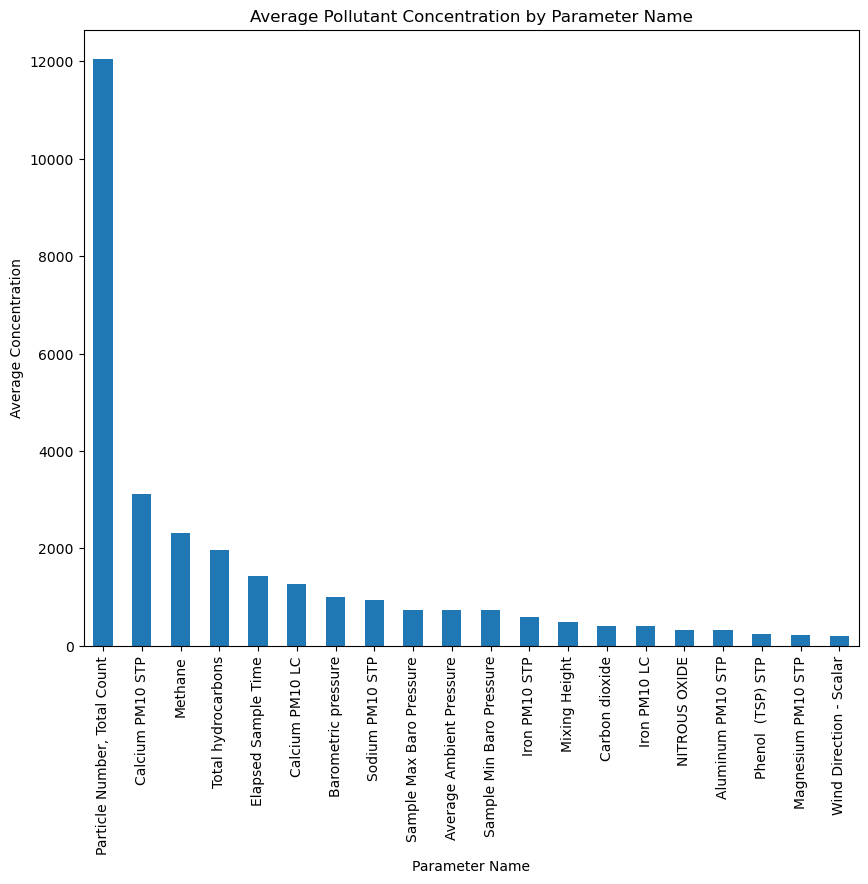

In [69]:
#visualize data 
#what are the top parameters we have metrics for?
# means by 
pollutant_means = air_data.groupby('Parameter Name')['Arithmetic Mean'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 8))
pollutant_means.plot(kind='bar')
plt.title('Average Pollutant Concentration by Parameter Name')
plt.xlabel('Parameter Name')
plt.ylabel('Average Concentration')
plt.xticks(rotation=90)
plt.show()


Maybe we can use dimensionality reduction to see which of these are really going to be interesting to look at...

In [70]:
#export data to csv for later use
air_data.to_csv('cleaned_air_quality_data.csv', index=False)